In [1]:
# Reload the pattern_logic_lib module to pick up debug changes
import importlib
from meteor import pattern_logic_lib
importlib.reload(pattern_logic_lib)
print("✅ Reloaded pattern_logic_lib with debug statements")

✅ Reloaded pattern_logic_lib with debug statements


## 1. Setup and Imports

In [2]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os
from matplotlib.gridspec import GridSpec
import warnings
import logging

# Suppress warnings
warnings.filterwarnings('ignore')

# Suppress ciceroscm logging warnings
logging.getLogger('ciceroscm').setLevel(logging.ERROR)

# METEOR Interface
from meteor import MeteorInterface, Cmip6MeteorDataGetter, geo_data_utils

print("✅ Imports complete")

✅ Imports complete


In [3]:
import gc  # For explicit garbage collection
import gcsfs  # For accessing CMIP6 data directly
import cftime  # For decoding time coordinates

In [4]:
# Set up output directory
FIGURE_DIR = '../paper_figures'
os.makedirs(FIGURE_DIR, exist_ok=True)

print(f"✅ Figure output directory: {os.path.abspath(FIGURE_DIR)}")

✅ Figure output directory: /Users/bensan/Documents/Github/METEOR/paper_figures


In [5]:
# Memory monitoring utility
import psutil
import os

def print_memory_usage():
    """Print current memory usage"""
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    mem_mb = mem_info.rss / 1024 / 1024
    mem_gb = mem_mb / 1024
    
    # System memory
    system_mem = psutil.virtual_memory()
    system_total_gb = system_mem.total / 1024 / 1024 / 1024
    system_used_gb = system_mem.used / 1024 / 1024 / 1024
    system_pct = system_mem.percent
    
    print(f"💾 Process memory: {mem_mb:.0f} MB ({mem_gb:.2f} GB)")
    print(f"💾 System memory: {system_used_gb:.1f}/{system_total_gb:.1f} GB ({system_pct:.1f}% used)")
    
    return mem_gb

print_memory_usage()

💾 Process memory: 315 MB (0.31 GB)
💾 System memory: 5.2/16.0 GB (79.4% used)


0.307373046875

## 2. Define Models and Scenarios

In [6]:
# Models to test (all have SSP5-3.4-overshoot data)
models = {
    'NorESM2-MM' : 'NorESM2-MM',
    'CanESM5': 'CanESM5',
    'CESM2-WACCM': 'CESM2-WACCM',
    'CNRM-ESM2-1': 'CNRM-ESM2-1',
    'IPSL-CM6A-LR': 'IPSL-CM6A-LR',
    'UKESM1-0-LL': 'UKESM1-0-LL'
}

# Training scenario
training_scenario = 'ssp245'

# Validation scenarios
validation_scenarios = {
    'ssp126': 'SSP1-2.6',
    'ssp245': 'SSP2-4.5 (in-sample)',
    'ssp585': 'SSP5-8.5',
 #   'ssp534-over': 'SSP5-3.4-OS'
}

print(f"Models to test: {len(models)}")
for model_code, model_name in models.items():
    print(f"  - {model_name}")

print(f"\nTraining: {training_scenario}")
print(f"\nValidation scenarios: {len(validation_scenarios)}")
for scenario_code, scenario_name in validation_scenarios.items():
    print(f"  - {scenario_name} ({scenario_code})")

Models to test: 6
  - NorESM2-MM
  - CanESM5
  - CESM2-WACCM
  - CNRM-ESM2-1
  - IPSL-CM6A-LR
  - UKESM1-0-LL

Training: ssp245

Validation scenarios: 3
  - SSP1-2.6 (ssp126)
  - SSP2-4.5 (in-sample) (ssp245)
  - SSP5-8.5 (ssp585)


In [7]:
# Storage for results - only store regional means, not gridded data
model_results = {}
cmip6_data = {}

# Time period for predictions
start_year = 2015
end_year = 2100

# Spatial aggregations to compute (we'll expand this list for regional analysis)
regions_to_compute = ['global']  # Future: add 'NH', 'SH', 'tropics', 'SREX_regions', etc.

print(f"Training and validating {len(models)} models...\n")
print(f"Time period: {start_year}-{end_year}")
print(f"Ensemble size: 100 realizations per scenario")
print(f"Spatial aggregations: {regions_to_compute}")
print(f"\n💡 Memory-efficient mode: Only storing regional means, not gridded data")
print("=" * 70)

Training and validating 6 models...

Time period: 2015-2100
Ensemble size: 100 realizations per scenario
Spatial aggregations: ['global']

💡 Memory-efficient mode: Only storing regional means, not gridded data


In [8]:
# Clear compressed cache files (if switching from compressed to uncompressed caching)
# This is needed because reading compressed files is very slow
import shutil
import glob

# Clear any potential lock files or stale cache
cache_cmip6_dir = '../cache/cmip6'
cache_pattern_dir = '../cache/pattern_scaling'

print(f"🗑️  Clearing cache directories to avoid lock issues...")

for cache_dir in [cache_cmip6_dir, cache_pattern_dir]:
    if os.path.exists(cache_dir):
        # Find and remove any .nc files (they might be compressed/locked)
        nc_files = glob.glob(os.path.join(cache_dir, '**/*.nc'), recursive=True)
        if nc_files:
            print(f"   Found {len(nc_files)} .nc files in {cache_dir}")
            shutil.rmtree(cache_dir)
            os.makedirs(cache_dir, exist_ok=True)
            print(f"   ✅ Cleared {cache_dir}")
        else:
            print(f"   ✅ {cache_dir} is clean")
    else:
        os.makedirs(cache_dir, exist_ok=True)
        print(f"   ✅ Created {cache_dir}")

print("✅ Cache directories ready")

🗑️  Clearing cache directories to avoid lock issues...
   ✅ ../cache/cmip6 is clean
   ✅ ../cache/pattern_scaling is clean
✅ Cache directories ready


In [9]:
import gc  # For explicit garbage collection

for model_code, model_name in models.items():
    print(f"\n{'='*70}")
    print(f"MODEL: {model_name}")
    print(f"{'='*70}")

    #try:
        # Initialize emulator
    print(f"\n1. Initializing emulator...")
    emulator = MeteorInterface(
        model=model_code,
        variables=['tas', 'pr'],
        cache_dir='../cache'
    )
    print(f"   ✅ Emulator initialized for {emulator.variables}")
    
    # Update emulator's data getter to include all validation scenarios
    print(f"\n2. Updating emulator data getter for all scenarios...")
    emulator.data_getter = Cmip6MeteorDataGetter(
        exps=["piControl", "historical", "ssp245", "abrupt-4xCO2", "ssp126", "ssp585"],
        flds=['tas', 'pr'],
        dbe=['CMIP', 'CMIP', 'ScenarioMIP', 'CMIP', 'ScenarioMIP', 'ScenarioMIP', 'ScenarioMIP'],
        enable_cache=True,
        enable_compression=False  # Disable compression for faster caching
    )
    print(f"   ✅ Data getter updated with all scenarios")
    
    # Get piControl baseline BEFORE training (compute once, use for all scenarios)
    print(f"\n3. Computing piControl baseline (global mean)...")
    picontrol_data_gridded = emulator.data_getter.make_meteor_training_data(
        "piControl", model_code, monthly=True
    )
    tas_picontrol_global = float(geo_data_utils.global_mean(picontrol_data_gridded['tas']).mean().values)
    
    # Immediately delete gridded piControl data
    del picontrol_data_gridded
    gc.collect()
    print(f"   ✅ piControl baseline: {tas_picontrol_global:.2f} K (gridded data cleared)")
    
    # Train model
    print(f"\n4. Training on {training_scenario}...")
    try:
        emulator.train(auto=True, verbose=True)
        print(f"   ✅ Training complete")
    except Exception as train_error:
        if "NaN" in str(train_error):
            print(f"\n   ⚠️  NaN error detected during training. Running diagnostics...")
            
            # Check training data for NaNs (use emulator's internal data getter)
            for variable in ['tas', 'pr']:
                print(f"\n   Checking {variable.upper()} training data:")
                
                try:
                    # Get the composite that's used for training
                    if hasattr(emulator, 'data_getter'):
                        train_data = emulator.data_getter.make_meteor_training_data_composite(
                            ["historical", "ssp245"], model_code, monthly=True
                        )[variable]
                    else:
                        print(f"     ⚠️  Cannot access emulator's data getter")
                        continue
                    
                    n_nans = np.isnan(train_data.values).sum()
                    n_total = train_data.values.size
                    pct_nan = (n_nans / n_total) * 100
                    
                    print(f"     Shape: {train_data.shape}")
                    print(f"     NaN count: {n_nans:,} / {n_total:,} ({pct_nan:.2f}%)")
                    
                    if n_nans > 0:
                        print(f"     ❌ Found NaN values in {variable} training data!")
                        
                        # Check per ensemble member if applicable
                        if train_data.ndim >= 3:
                            for ens_idx in range(min(train_data.shape[0], 10)):  # Check first 10
                                ens_nans = np.isnan(train_data.values[ens_idx]).sum()
                                if ens_nans > 0:
                                    pct = (ens_nans / train_data.values[ens_idx].size) * 100
                                    print(f"        Ensemble {ens_idx}: {ens_nans:,} NaNs ({pct:.2f}%)")
                    else:
                        print(f"     ✅ No NaN values in {variable} training data")
                        
                except Exception as diag_error:
                    print(f"     ❌ Error checking training data: {str(diag_error)}")
            
            # Check forcing data (ERF)
            print(f"\n   Checking forcing data:")
            try:
                # Check abrupt-4xCO2 data used for ERF calculation
                if hasattr(emulator, 'data_getter'):
                    abrupt_data = emulator.data_getter.make_meteor_training_data(
                        "abrupt-4xCO2", model_code, monthly=True
                    )
                
                for variable in ['tas', 'pr']:
                    if variable in abrupt_data:
                        n_nans = np.isnan(abrupt_data[variable].values).sum()
                        n_total = abrupt_data[variable].values.size
                        pct_nan = (n_nans / n_total) * 100
                        print(f"     abrupt-4xCO2 {variable.upper()}: {n_nans:,} / {n_total:,} NaNs ({pct_nan:.2f}%)")
                
                # Try to compute ERF to see if NaN appears there
                print(f"   Attempting ERF calculation...")
                if hasattr(emulator, 'data_getter') and hasattr(emulator.data_getter, 'get_erf'):
                    try:
                        erf_data = emulator.data_getter.get_erf(model_code)
                        if erf_data is not None:
                            n_nans = np.isnan(erf_data.values).sum()
                            n_total = erf_data.values.size
                            pct_nan = (n_nans / n_total) * 100
                            print(f"     ERF data: {n_nans:,} / {n_total:,} NaNs ({pct_nan:.2f}%)")
                            if n_nans > 0:
                                print(f"     ❌ Found NaN values in ERF calculation!")
                    except Exception as erf_error:
                        print(f"     ❌ Error computing ERF: {str(erf_error)}")
                
            except Exception as forcing_error:
                print(f"     ❌ Error checking forcing data: {str(forcing_error)}")
            
            # Check pattern scaling data
            print(f"\n   Checking pattern scaling preparation:")
            try:
                if hasattr(emulator, 'pattern_scaler'):
                    for variable in ['tas', 'pr']:
                        if variable in emulator.pattern_scaler:
                            ps = emulator.pattern_scaler[variable]
                            if hasattr(ps, 'patterns') and ps.patterns is not None:
                                n_nans = np.isnan(ps.patterns.values).sum()
                                n_total = ps.patterns.values.size
                                pct_nan = (n_nans / n_total) * 100
                                print(f"     {variable.upper()} patterns: {n_nans:,} / {n_total:,} NaNs ({pct_nan:.2f}%)")
            except Exception as ps_error:
                print(f"     ❌ Error checking pattern scaling: {str(ps_error)}")
            
            print(f"\n   Original error: {str(train_error)}")
        
        raise  # Re-raise the exception
    
    # Initialize storage for this model
    model_results[model_code] = {'picontrol_baseline': tas_picontrol_global}
    cmip6_data[model_code] = {}
    
    # Generate predictions for all validation scenarios
    print(f"\n5. Generating predictions for validation scenarios...")
    for scenario_code, scenario_name in validation_scenarios.items():
        print(f"   → {scenario_name}...")
        
        # 🔑 KEY: By passing timeseries=['global'] and NOT passing gridded={},
        # METEOR generates ensemble in EOF/PC space and projects to regional means
        # on-the-fly. Full gridded data (100 × 64k gridpoints × 1032 months) is 
        # NEVER materialized in memory - only the timeseries are computed and returned.
        # The trained EOFs and patterns are already in memory from training (~few MB).
        ensemble = emulator.generate_ensemble_outputs(
            scenario=scenario_code,
            start_year=start_year,
            end_year=end_year,
            n_realizations=100,
            timeseries=regions_to_compute,  # Projects EOFs → regions (no grids!)
            verbose=False
        )
        
        # Store ONLY the timeseries (regional means), not gridded data
        model_results[model_code][scenario_code] = {
            'tas': ensemble['tas'].timeseries['global'],  # Shape: (n_realizations, n_months)
            'pr': ensemble['pr'].timeseries['global']
        }
        
        # Immediately delete the full ensemble object to free memory
        del ensemble
        gc.collect()
        
        # ========== FIX: Extract correct time slice from CMIP6 data ==========
        # Get zstore reference to decode actual time coordinates
        exp_idx = emulator.data_getter.exps.index(scenario_code)
        fld_idx = emulator.data_getter.flds.index('tas')
        model_idx = emulator.data_getter.models.index(model_code)
        zstore_ref = emulator.data_getter.df_all[exp_idx][fld_idx].loc[model_idx].zstore
        
        # Load raw data to decode time and find correct indices
        gcs = gcsfs.GCSFileSystem(token='anon')
        mapper = gcs.get_mapper(zstore_ref)
        raw_ds = xr.open_zarr(mapper, decode_times=False)
        
        # Decode time to find indices for target year range
        if 'units' in raw_ds.time.attrs:
            units = raw_ds.time.attrs['units']
            calendar = raw_ds.time.attrs.get('calendar', 'standard')
            time_decoded = cftime.num2date(raw_ds.time.values, units, calendar)
            
            # Find indices matching our target year range
            target_indices = [i for i, t in enumerate(time_decoded) 
                                if start_year <= t.year <= end_year]
            
            if len(target_indices) == 0:
                print(f"      ⚠️  No data for {start_year}-{end_year} in {scenario_code}")
                raw_ds.close()
                continue
            
            start_idx = target_indices[0]
            end_idx = target_indices[-1] + 1  # +1 for inclusive slicing
            
            actual_start_year = time_decoded[start_idx].year
            actual_end_year = time_decoded[end_idx-1].year
            
            print(f"      Extracting months {start_idx}-{end_idx-1} (years {actual_start_year}-{actual_end_year}) "
                    f"out of {len(raw_ds.time)} total")
        else:
            # Fallback: assume data starts at start_year
            print(f"      WARNING - no time units, assuming starts at {start_year}")
            n_months_needed = (end_year - start_year + 1) * 12
            start_idx = 0
            end_idx = min(n_months_needed, len(raw_ds.time))
            actual_start_year = start_year
            actual_end_year = end_year
        
        raw_ds.close()
        
        # Now load the data through the data getter and slice to correct range
        cmip6_raw_full = emulator.data_getter.make_meteor_training_data(
            scenario_code, model_code, monthly=True
        )
        
        # Slice to the correct time range
        cmip6_raw = cmip6_raw_full.isel(month=slice(start_idx, end_idx))
        
        # Calculate global means (these are small: just timeseries)
        tas_global = geo_data_utils.global_mean(cmip6_raw['tas'])
        pr_global = geo_data_utils.global_mean(cmip6_raw['pr'])
        
        # Convert temperature to anomaly using pre-computed baseline
        tas_global_anom = tas_global - tas_picontrol_global
        
        # Store the timeseries with alignment info
        cmip6_data[model_code][scenario_code] = {
            'tas': tas_global_anom,
            'pr': pr_global,
            'alignment': {
                'method': 'time_decoded',
                'cmip6_range': (actual_start_year, actual_end_year),
                'indices_used': (start_idx, end_idx),
                'total_months_available': len(cmip6_raw_full['tas']['month'])
            }
        }
        
        # Immediately delete gridded CMIP6 data
        del cmip6_raw_full, cmip6_raw, tas_global, pr_global
        gc.collect()
        
        print("      ✅ CMIP6 data loaded and sliced correctly")
    
    print(f"\n   ✅ All predictions complete for {model_name}")
    print(f"   💾 Memory: Stored only timeseries data (gridded data cleared)")
    
    # Print alignment diagnostics for SSP5-3.4-over
    if 'ssp534-over' in cmip6_data[model_code]:
        align_info = cmip6_data[model_code]['ssp534-over'].get('alignment', {})
        if 'cmip6_range' in align_info:
            cmip6_start, cmip6_end = align_info['cmip6_range']
            overlap_start, overlap_end = align_info['overlap_range']
            print(f"   📊 SSP5-3.4-OS alignment: CMIP6 spans {cmip6_start}-{cmip6_end}, overlap: {overlap_start}-{overlap_end}")
    
    # Clean up emulator to free memory before next model
    del emulator
    gc.collect()
    
    # except Exception as e:
    #     print(f"\n   ❌ Error processing {model_name}: {str(e)}")
    #     import traceback
    #     traceback.print_exc()
        
    #     # Clean up on error
    #     if 'emulator' in locals():
    #         del emulator
    #     gc.collect()
    #     continue

print(f"\n{'='*70}")
print(f"✅ Processing complete. {len(model_results)} models successful.")
print(f"{'='*70}")


MODEL: NorESM2-MM

1. Initializing emulator...
   ✅ Emulator initialized for ['tas', 'pr']

2. Updating emulator data getter for all scenarios...
   ✅ Data getter updated with all scenarios

3. Computing piControl baseline (global mean)...
   ✅ piControl baseline: 286.92 K (gridded data cleared)

4. Training on ssp245...
Training METEOR emulator for NorESM2-MM
Variables: tas, pr

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-NorESM2-MM-aer', found 'cmip6-NorESM2-MM-aer-tas'
🔧 Preparing pattern scaling training data for NorESM2-MM...
   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 751 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
✅ Pattern scaling model lo

TypeError: Improper input: func input vector length N=6 must not exceed func output vector length M=5

In [11]:
# Check which models were successfully processed
print("Successfully processed models:")
for model_code in model_results.keys():
    print(f"  ✅ {models[model_code]}")

failed_models = set(models.keys()) - set(model_results.keys())
if failed_models:
    print("\nFailed models:")
    for model_code in failed_models:
        print(f"  ❌ {models[model_code]}")

Successfully processed models:
  ✅ NorESM2-MM
  ✅ CanESM5
  ✅ CESM2-WACCM
  ✅ CNRM-ESM2-1

Failed models:
  ❌ IPSL-CM6A-LR
  ❌ UKESM1-0-LL


In [12]:
# Check memory usage after processing
print("\n💾 Final memory usage:")
final_mem_gb = print_memory_usage()

# Calculate approximate data size
if len(model_results) > 0:
    # Estimate timeseries storage
    first_model = list(model_results.keys())[0]
    first_scenario = list(validation_scenarios.keys())[0]
    
    n_models = len(model_results)
    n_scenarios = len(validation_scenarios)
    n_variables = 2  # tas, pr
    n_realizations = model_results[first_model][first_scenario]['tas'].shape[0]
    n_months = model_results[first_model][first_scenario]['tas'].shape[1]
    
    # Each float64 value = 8 bytes
    approx_size_mb = (n_models * n_scenarios * n_variables * n_realizations * n_months * 8) / (1024**2)
    
    print(f"\n📊 Data stored:")
    print(f"   Models: {n_models}")
    print(f"   Scenarios per model: {n_scenarios}")
    print(f"   Variables: {n_variables} (tas, pr)")
    print(f"   Ensemble members: {n_realizations}")
    print(f"   Time steps: {n_months} months")
    print(f"   Approximate storage: {approx_size_mb:.1f} MB (timeseries only)")



💾 Final memory usage:
💾 Process memory: 1451 MB (1.42 GB)
💾 System memory: 8.2/16.0 GB (59.6% used)

📊 Data stored:
   Models: 4
   Scenarios per model: 3
   Variables: 2 (tas, pr)
   Ensemble members: 100
   Time steps: 1032 months
   Approximate storage: 18.9 MB (timeseries only)


In [13]:
# Create time axis (same for both METEOR and CMIP6 now)
if len(model_results) > 0:
    first_model = list(model_results.keys())[0]
    n_months = model_results[first_model]['ssp245']['tas'].shape[1]
    years = start_year + np.arange(n_months) / 12

    print(f"Time range: {years[0]:.0f} - {years[-1]:.0f} ({len(years)} months)")
    print(f"✅ METEOR and CMIP6 data aligned to same time range")
else:
    print("⚠️  No models successfully processed yet.")

Time range: 2015 - 2101 (1032 months)
✅ METEOR and CMIP6 data aligned to same time range


## 4. Visualization - Individual Model Plots

Create separate validation plots for each model, using consistent color scheme:
- **Temperature**: Orange-red (#E76F51 mean, #F4A261 uncertainty)
- **Precipitation**: Blue (#61A1F4 mean, #51C4E7 uncertainty)  
- **CMIP6 comparison**: Black with transparency


Generating plot for NorESM2-MM...


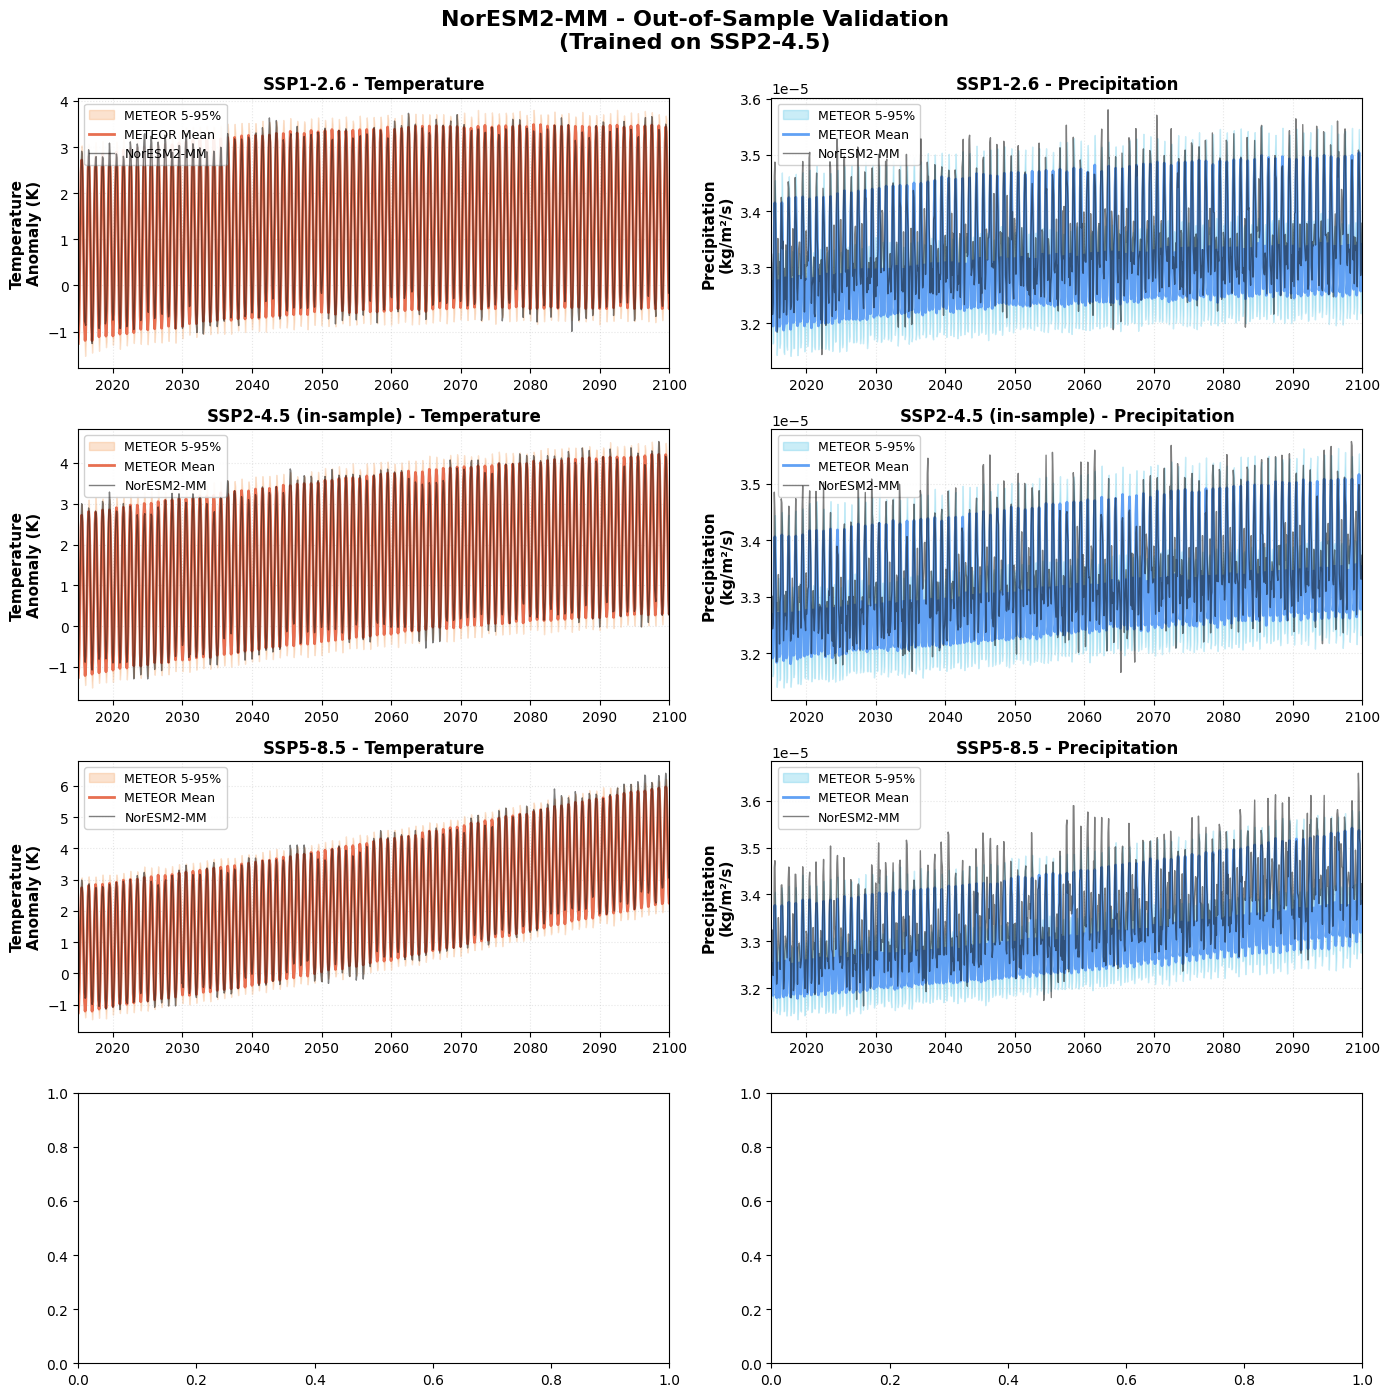

   ✅ Saved to: ../paper_figures/fig7_NorESM2-MM_validation.pdf

Generating plot for CanESM5...


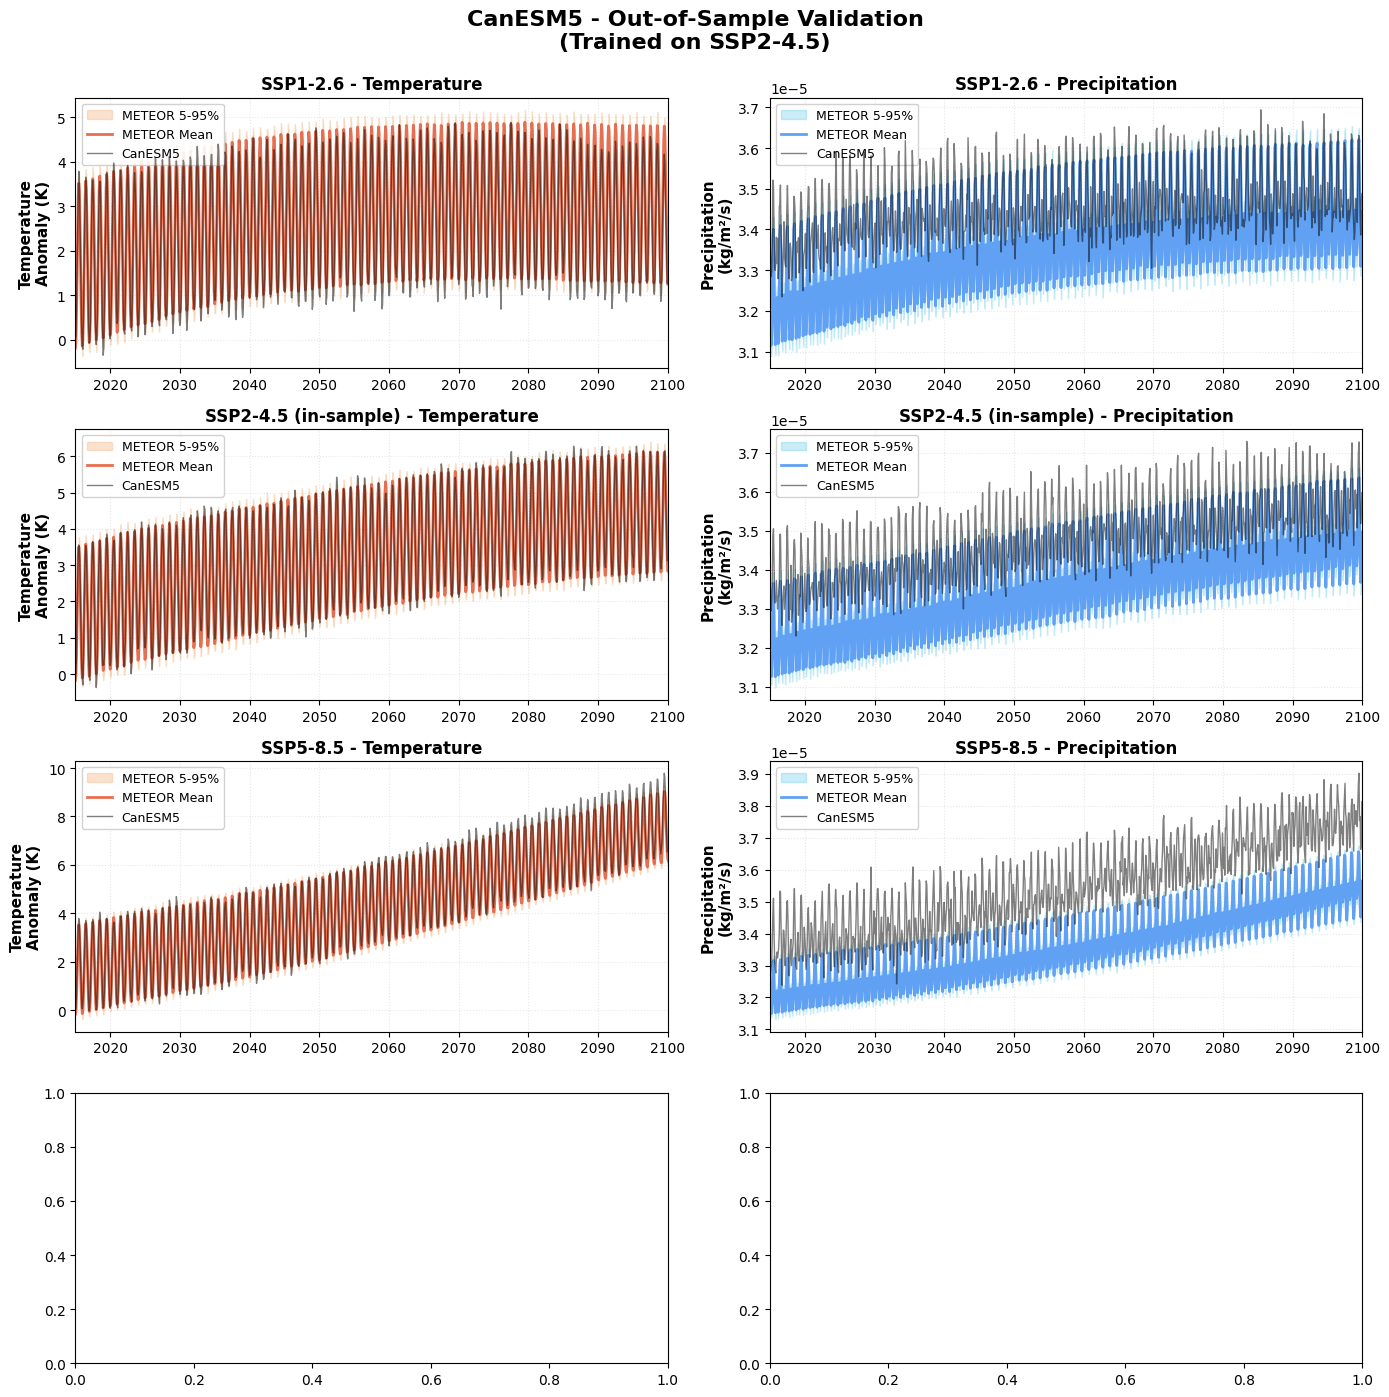

   ✅ Saved to: ../paper_figures/fig7_CanESM5_validation.pdf

Generating plot for CESM2-WACCM...


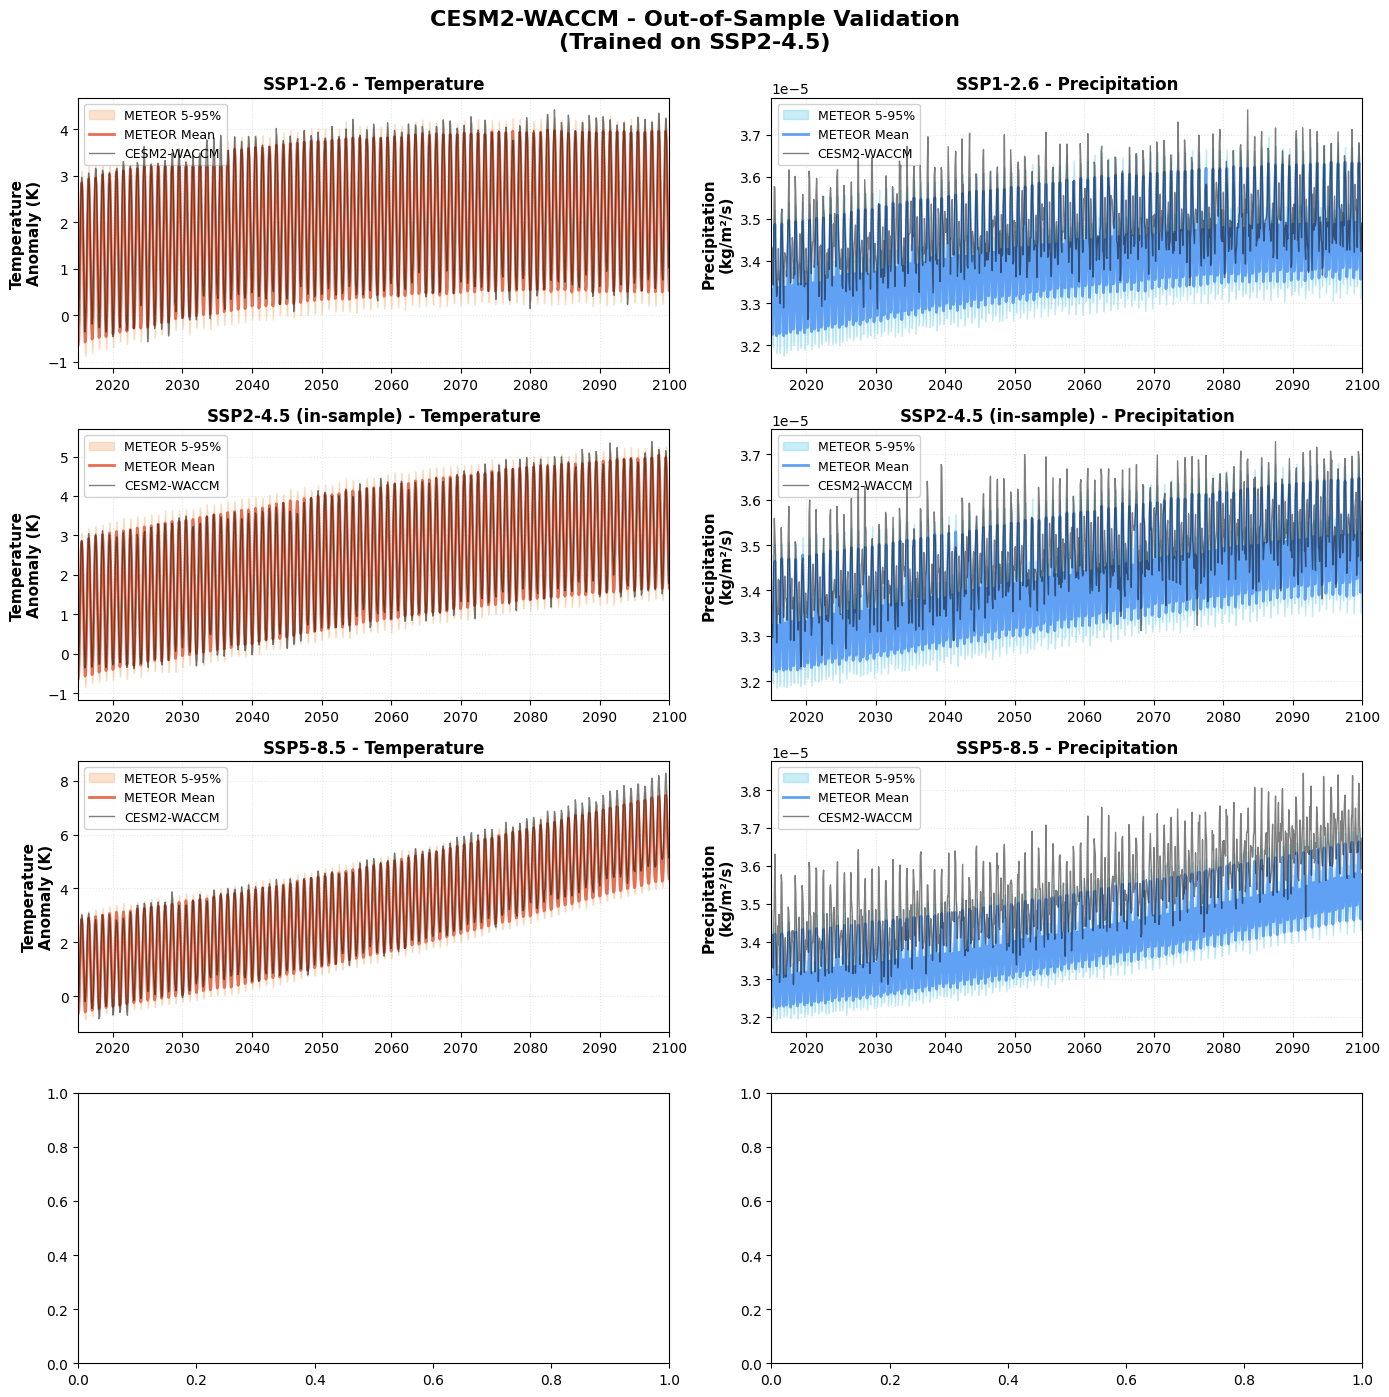

   ✅ Saved to: ../paper_figures/fig7_CESM2-WACCM_validation.pdf

Generating plot for CNRM-ESM2-1...


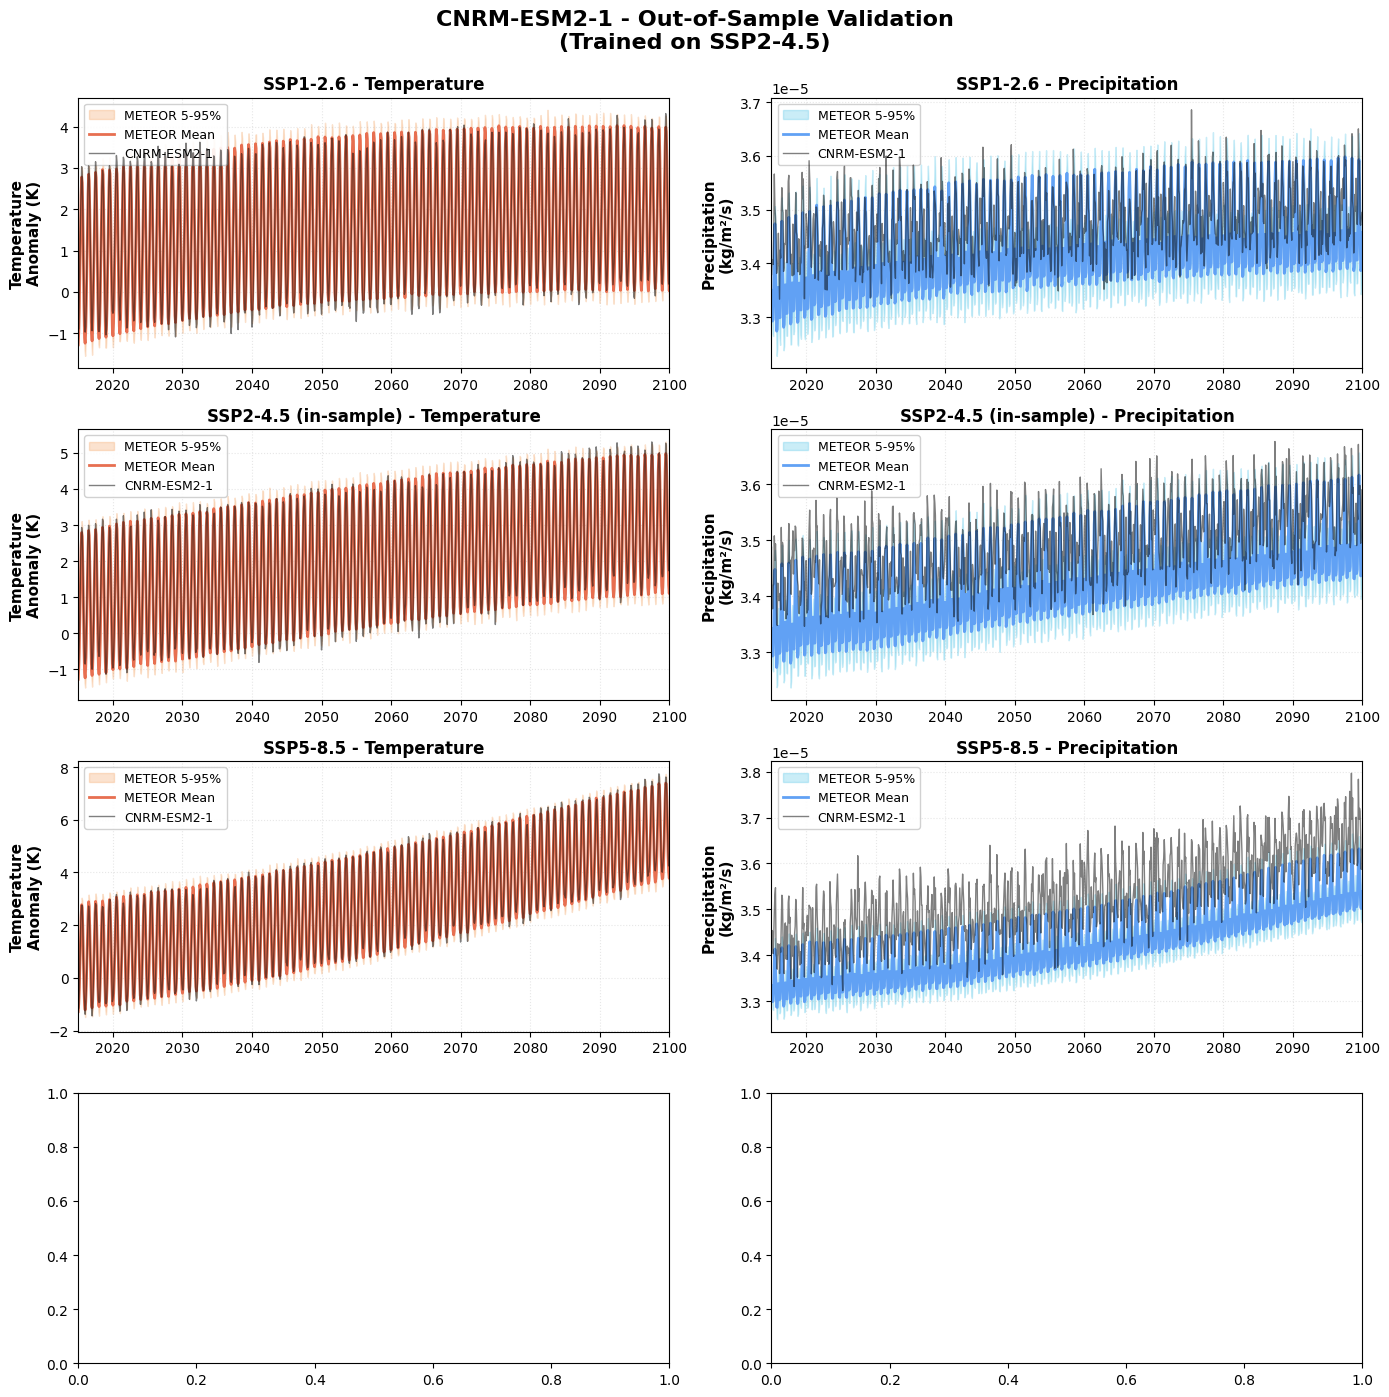

   ✅ Saved to: ../paper_figures/fig7_CNRM-ESM2-1_validation.pdf

✅ All model validation plots complete
   Generated 4 separate figures


In [14]:
if len(model_results) == 0:
    print("⚠️  No models to visualize. Run training cells first.")
else:
    # Define colors matching Interface_Paper_plots style
    tas_color_mean = '#E76F51'      # Orange-red for temperature mean
    tas_color_uncertainty = '#F4A261'  # Light orange for temperature uncertainty
    pr_color_mean = '#61A1F4'       # Blue for precipitation mean
    pr_color_uncertainty = '#51C4E7'   # Light blue for precipitation uncertainty
    cmip6_color = 'black'           # Black for CMIP6 reference
    
    # Create separate figure for each model
    for model_code, model_name in models.items():
        if model_code not in model_results:
            continue
        
        print(f"\nGenerating plot for {model_name}...")
        
        # Create 4x2 grid (4 scenarios, temp + precip)
        fig, axes = plt.subplots(4, 2, figsize=(14, 14))
        fig.suptitle(f'{model_name} - Out-of-Sample Validation\n(Trained on SSP2-4.5)', 
                     fontsize=16, fontweight='bold', y=0.995)
        
        for row_idx, (scenario_code, scenario_name) in enumerate(validation_scenarios.items()):
            
            # === Temperature (left column) ===
            ax_t = axes[row_idx, 0]
            
            # Get METEOR data
            tas_data = model_results[model_code][scenario_code]['tas']
            tas_mean = tas_data.mean(axis=0)
            tas_p5 = np.percentile(tas_data, 5, axis=0)
            tas_p95 = np.percentile(tas_data, 95, axis=0)
            
            # Plot METEOR ensemble
            ax_t.fill_between(years, tas_p5, tas_p95, color=tas_color_uncertainty, alpha=0.3, label='METEOR 5-95%')
            ax_t.plot(years, tas_mean, color=tas_color_mean, linewidth=2, label='METEOR Mean')
            
            # Get CMIP6 data and alignment info
            cmip6_tas = cmip6_data[model_code][scenario_code]['tas']
            alignment_info = cmip6_data[model_code][scenario_code].get('alignment', {})
            
            if cmip6_tas.ndim == 2:
                cmip6_tas_mean = cmip6_tas.mean(dim='ens').values
            else:
                cmip6_tas_mean = cmip6_tas.values
            
            # Create time axis for CMIP6 based on alignment
            if 'overlap_range' in alignment_info:
                overlap_start, overlap_end = alignment_info['overlap_range']
                n_months_overlap = len(cmip6_tas_mean)
                years_cmip6 = overlap_start + np.arange(n_months_overlap) / 12
            else:
                # Fallback: align to end of METEOR period
                n_months_cmip6 = len(cmip6_tas_mean)
                years_cmip6 = end_year - n_months_cmip6/12 + np.arange(n_months_cmip6) / 12
            
            # Plot CMIP6
            ax_t.plot(years_cmip6, cmip6_tas_mean, color=cmip6_color, linewidth=1, 
                     linestyle='-', label=model_name, alpha=0.5, zorder=10)
            
            ax_t.set_ylabel('Temperature\nAnomaly (K)', fontsize=11, fontweight='bold')
            ax_t.set_title(f'{scenario_name} - Temperature', fontsize=12, fontweight='bold')
            ax_t.grid(True, alpha=0.3, linestyle=':')
            ax_t.set_xlim([start_year, end_year])
            ax_t.legend(fontsize=9, loc='upper left', framealpha=0.9)
            
            if row_idx == 3:
                ax_t.set_xlabel('Year', fontsize=11, fontweight='bold')
            
            # === Precipitation (right column) ===
            ax_p = axes[row_idx, 1]
            
            # Get METEOR data
            pr_data = model_results[model_code][scenario_code]['pr']
            pr_mean = pr_data.mean(axis=0)
            pr_p5 = np.percentile(pr_data, 5, axis=0)
            pr_p95 = np.percentile(pr_data, 95, axis=0)
            
            # Plot METEOR ensemble
            ax_p.fill_between(years, pr_p5, pr_p95, color=pr_color_uncertainty, alpha=0.3, label='METEOR 5-95%')
            ax_p.plot(years, pr_mean, color=pr_color_mean, linewidth=2, label='METEOR Mean')
            
            # Get CMIP6 data
            cmip6_pr = cmip6_data[model_code][scenario_code]['pr']
            if cmip6_pr.ndim == 2:
                cmip6_pr_mean = cmip6_pr.mean(dim='ens').values
            else:
                cmip6_pr_mean = cmip6_pr.values
            
            # Use same time axis as temperature
            # Plot CMIP6
            ax_p.plot(years_cmip6, cmip6_pr_mean, color=cmip6_color, linewidth=1, 
                     linestyle='-', label=model_name, alpha=0.5, zorder=10)
            
            ax_p.set_ylabel('Precipitation\n(kg/m²/s)', fontsize=11, fontweight='bold')
            ax_p.set_title(f'{scenario_name} - Precipitation', fontsize=12, fontweight='bold')
            ax_p.grid(True, alpha=0.3, linestyle=':')
            ax_p.set_xlim([start_year, end_year])
            ax_p.legend(fontsize=9, loc='upper left', framealpha=0.9)
            
            if row_idx == 3:
                ax_p.set_xlabel('Year', fontsize=11, fontweight='bold')
        
        plt.tight_layout()
        
        # Save with model name in filename
        filename = f'fig7_{model_code}_validation.pdf'
        plt.savefig(os.path.join(FIGURE_DIR, filename), bbox_inches='tight', dpi=300)
        plt.show()
        
        print(f"   ✅ Saved to: {os.path.join(FIGURE_DIR, filename)}")

    print(f"\n✅ All model validation plots complete")
    print(f"   Generated {len(model_results)} separate figures")

## 5. Quantitative Validation Metrics

Calculate error metrics for each model and scenario.

In [15]:
if len(model_results) == 0:
    print("⚠️  No models to analyze. Run training cells first.")
else:
    print("="*90)
    print("VALIDATION METRICS: METEOR vs CMIP6")
    print("="*90)

    for model_code, model_name in models.items():
        if model_code not in model_results:
            continue
        
        print(f"\n{model_name}:")
        print("-" * 90)
        
        for scenario_code, scenario_name in validation_scenarios.items():
            # Get data
            meteor_tas = model_results[model_code][scenario_code]['tas'].mean(axis=0)
            meteor_pr = model_results[model_code][scenario_code]['pr'].mean(axis=0)
            
            cmip6_tas = cmip6_data[model_code][scenario_code]['tas']
            cmip6_pr = cmip6_data[model_code][scenario_code]['pr']
            
            if cmip6_tas.ndim == 2:
                cmip6_tas = cmip6_tas.mean(dim='ens').values
                cmip6_pr = cmip6_pr.mean(dim='ens').values
            else:
                cmip6_tas = cmip6_tas.values
                cmip6_pr = cmip6_pr.values
            
            # Align time dimensions
            n_min = min(len(meteor_tas), len(cmip6_tas))
            meteor_tas_sub = meteor_tas[:n_min]
            meteor_pr_sub = meteor_pr[:n_min]
            cmip6_tas_sub = cmip6_tas[:n_min]
            cmip6_pr_sub = cmip6_pr[:n_min]
            
            # Calculate metrics
            tas_rmse = np.sqrt(np.mean((meteor_tas_sub - cmip6_tas_sub)**2))
            tas_bias = np.mean(meteor_tas_sub - cmip6_tas_sub)
            tas_corr = np.corrcoef(meteor_tas_sub, cmip6_tas_sub)[0, 1]
            
            pr_rmse = np.sqrt(np.mean((meteor_pr_sub - cmip6_pr_sub)**2))
            pr_bias = np.mean(meteor_pr_sub - cmip6_pr_sub)
            pr_corr = np.corrcoef(meteor_pr_sub, cmip6_pr_sub)[0, 1]
            
            print(f"  {scenario_name:25s} | TAS RMSE: {tas_rmse:.4f} K | Bias: {tas_bias:+.4f} K | Corr: {tas_corr:.4f}")
            print(f"  {' ':25s} | PR  RMSE: {pr_rmse:.6f}   | Bias: {pr_bias:+.6f}   | Corr: {pr_corr:.4f}")

    print("\n" + "="*90)
    print("✅ Validation metrics complete")
    print("="*90)

VALIDATION METRICS: METEOR vs CMIP6

NorESM2-MM:
------------------------------------------------------------------------------------------
  SSP1-2.6                  | TAS RMSE: 0.1829 K | Bias: -0.0153 K | Corr: 0.9919
                            | PR  RMSE: 0.000001   | Bias: -0.000000   | Corr: 0.8869
  SSP2-4.5 (in-sample)      | TAS RMSE: 0.1954 K | Bias: -0.0160 K | Corr: 0.9912
                            | PR  RMSE: 0.000001   | Bias: -0.000000   | Corr: 0.8947
  SSP5-8.5                  | TAS RMSE: 0.2174 K | Bias: -0.0099 K | Corr: 0.9925
                            | PR  RMSE: 0.000001   | Bias: -0.000001   | Corr: 0.8881

CanESM5:
------------------------------------------------------------------------------------------
  SSP1-2.6                  | TAS RMSE: 0.2620 K | Bias: +0.1997 K | Corr: 0.9918
                            | PR  RMSE: 0.000001   | Bias: -0.000001   | Corr: 0.9287
  SSP2-4.5 (in-sample)      | TAS RMSE: 0.1598 K | Bias: -0.0180 K | Corr: 0.9944
     